# HSLS Staged Benchmark -- Binary STEM Task vs. 11-Class Major Task

**Purpose:** Build the progressive evidence chain requested by the supervisor: does
performance on a simpler, published-comparable task (binary STEM/non-STEM) respond to
progressively richer student information the way the thesis argues it should, and how
does performance change when task complexity increases from binary to the final
11-category major classification?

**This notebook is an HSLS binary benchmark aligned with published STEM-major-choice
research (Nagy et al., 2023; Chang et al., 2023) -- it is NOT presented as an exact
replication of either paper.** Nagy et al. do not report the exact HSLS variable code
underlying their target, so alignment (not replication) is the honest claim. Chang et
al.'s published target (`X4RFDGMJSTEM`) is confirmed by the codebook to measure a
different construct (STEM status of a *reference completed/declared degree*) than the
entry-intent construct used here and throughout this thesis -- this notebook does not
claim to reproduce Chang et al.

**Dataset:** HSLS:09 restricted-use student file, filtered per-stage as described below.

**Target:** `X4ENTMJST` -- "X4 Major considering upon postsecondary entry is in a
science, technology, engineering, or math (STEM) field" (official NCES composite).
Confirmed via the codebook to be a **sibling** of `X4ENTRYMAJ4Y`, not derived from it:
both are built independently from the same base survey item, `S4FIELD6`, using two
different classification schemes (a CIP-range STEM test vs. the 23-then-11-category
major aggregation). The analytical sample is determined directly from `X4ENTMJST`'s own
valid values (`{0, 1}` only) -- it is not inferred by subtracting the 695
`X4ENTRYMAJ4Y`-undecided records, even though that arithmetic happens to agree (both
composites share the same `-1` undecided count by construction from `S4FIELD6`).

**Predictors:** the eligible subset of the same 377 Set D predictors, after an explicit
leakage audit (below) against the binary target and the second-follow-up wave the
target is drawn from. **The frozen eligible set is used unchanged across Stages 1-6** --
only which dimensions are *included* changes between stages; no predictor is
reprocessed differently, retuned, or reselected per stage.

**Experimental role:** Staged benchmark / information-richness ablation. Stages 1-6 use
one frozen model protocol (same preprocessing, same untuned CatBoost hyperparameters,
same random state, same SMOTE placement) -- **no stage is tuned independently to
maximize its own score.** Stage 7 is not run here; it is the existing, unmodified
11-class `X4ENTRYMAJ4Y` V3 CatBoost result (Macro-F1 = 0.2287), included only as a
fixed reference point for the final comparison table.

**Primary metric:** Macro-F1, reported alongside Accuracy, ROC-AUC, per-class
Precision/Recall/F1, and 5-fold CV Macro-F1 mean/SD for the binary stages.

**Random state:** 42 (identical to every other notebook in this thesis).

**Determinism note:** an earlier version of this notebook fit the full 377-predictor
model independently for both Stage 1 and Stage 6 and found they did not match exactly
(0.7007 vs. 0.7097 Macro-F1), despite using the same predictor *set*. The cause was
column *order*: Stage 1 used the decision table's original variable order while Stage
6 was built by concatenating separately-collected dimension groups, producing the same
377 variables in a different order. CatBoost's split search and SMOTE's neighbor
search are order-sensitive even at a fixed `random_state`. This is fixed by (1) an
`ordered_subset()` helper that presents every stage's predictors in one canonical
order, and (2) reusing Stage 1's fitted result directly as Stage 6 rather than
refitting -- see the "Run Stages 1-6" section. `thread_count=1` is also set on
CatBoost for additional bit-exact reproducibility.

**Stage design:**

| Stage | Predictor dimensions included | Target |
|---|---|---|
| 1 | Full eligible set (all 5 dimensions) | `X4ENTMJST` (binary) |
| 2 | Academic performance/preparation only | `X4ENTMJST` (binary) |
| 3 | + Career interests and aspirations | `X4ENTMJST` (binary) |
| 4 | + Skills and self-efficacy | `X4ENTMJST` (binary) |
| 5 | + Behavioral/psychological factors | `X4ENTMJST` (binary) |
| 6 | + Demographic/SES controls (= full eligible set again) | `X4ENTMJST` (binary) |
| 7 | Full 377 Set D predictors (existing, unmodified) | `X4ENTRYMAJ4Y` (11-class) |

Stage 6's cumulative predictor set equals Stage 1's full eligible set, so **Stage 6
reuses Stage 1's fitted result directly rather than being independently refit** -- see
the determinism note below and the "Run Stages 1-6" section for why this is a
correctness fix, not just an optimization.

**Output files:** `predictor_leakage_audit.csv`, `staged_benchmark_results.csv`,
`fig_staged_benchmark_macro_f1.png`, plus a confusion matrix and classification report
CSV for Stage 1.


## (Optional) Mount Google Drive

In [1]:
try:
    from google.colab import drive
    drive.mount('/content/drive')
except ImportError:
    print("Not running in Colab -- skipping Drive mount (expected for local VS Code runs).")


Mounted at /content/drive


## Install / Import

In [2]:
!pip install imbalanced-learn --quiet
!pip install catboost --quiet

import os
import re
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder, MinMaxScaler, OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline as SkPipeline
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.base import BaseEstimator, TransformerMixin, ClassifierMixin
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report,
)

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

from catboost import CatBoostClassifier


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.6 MB/s eta 0:00:00


### CONFIG

`RAW_HSLS_PATH` points at the full restricted-use student file (the same source
`prepare_dataset_for_pipeline` reads from) -- `X4ENTMJST` is not present in your
already-prepared `prepared_hsls_setD_4Y.csv`, so it must be read from the raw file
directly. Everything else matches the frozen V3 CatBoost configuration exactly.

In [3]:
RAW_HSLS_PATH = "/content/drive/MyDrive/newbenchmark/hsls09_16_student_pets_pear_v1_0.csv"
DECISION_TABLE_PATH = "/content/drive/MyDrive/newbenchmark/HSLS_final_predictor_decision_table.csv"
SETE_AUDIT_PATH = "/content/drive/MyDrive/newbenchmark/HSLS_SetE_feature_audit.csv"
CODEBOOK_TXT_PATH = "/content/drive/MyDrive/newbenchmark/Codebook_HSLS_2009-16_PETS_Pear.txt"

RANDOM_STATE = 42
TARGET_COL_BINARY = "X4ENTMJST"
TARGET_COL_11CLASS = "program_stream"   # X4ENTRYMAJ4Y, for reference only (Stage 7 -- not recomputed here)

OUTPUT_DIR = "/content/drive/MyDrive/newbenchmark/output3"
def out_path(filename: str) -> str:
    return f"{OUTPUT_DIR.rstrip('/')}/{filename}"

# Identical CatBoost defaults to every other notebook in this thesis. NOT retuned per
# stage -- this is the whole point of a controlled comparison.
#
# thread_count=1 is added here (not present in the earlier V1-V6/CatBoost notebooks)
# purely for bit-exact reproducibility: CatBoost's multi-threaded histogram/split
# search can produce tiny floating-point differences between runs of the SAME
# predictor set purely from thread-scheduling order, on top of the larger, separate
# column-order effect fixed below. thread_count does not change model capacity or
# behavior in principle -- it only removes a source of run-to-run non-determinism --
# so this is not a hyperparameter change made to improve performance.
CATBOOST_DEFAULTS = dict(
    iterations=500, depth=6, learning_rate=0.1, l2_leaf_reg=3.0,
    early_stopping_rounds=30, val_size=0.15, random_state=RANDOM_STATE, verbose=False,
    thread_count=1,
)

# The explicit target-family exclusion list -- checked by name before any keyword
# scan. These are the target itself and its direct source/sibling variables.
EXPLICIT_TARGET_FAMILY = {
    "X4ENTMJST", "X4ENTMJSTNSF", "X4ENTRYMAJ23", "X4ENTRYMAJ4Y", "X4ENTRYMAJ2Y",
    "S4FIELD", "S4FIELD2", "S4FIELD6",
}

# Dimension display names -- identical to the FINAL SHAP notebook's DIMENSION_RENAME,
# reused here as the single canonical mapping (not re-derived).
DIMENSION_RENAME = {
    "Academic performance": "Academic performance/preparation",
    "Career interests and aspirations": "Career interests and aspirations",
    "Skills and self-efficacy": "Skills and self-efficacy",
    "Behavioral or psychological factors": "Behavioral/psychological factors",
    "Demographic or socioeconomic controls": "Demographic/SES controls",
}

# The same manually verified Top-30 dimension override applied in the FINAL SHAP
# notebook -- reused unchanged, per the instruction to use the already-verified
# mapping rather than re-deriving or auto-reclassifying anything.
MANUAL_TOP30_DIMENSION_MAP = {
    "X2SEX": "Demographic/SES controls", "S2SCAREER": "Career interests and aspirations",
    "S2SEX": "Demographic/SES controls", "S2MCAREER": "Career interests and aspirations",
    "X1SEX": "Demographic/SES controls", "X2SCIID": "Skills and self-efficacy",
    "S2FAVSUBJ": "Career interests and aspirations", "X2MTHID": "Skills and self-efficacy",
    "S2SUSEJOB": "Career interests and aspirations", "X3THIPHY": "Academic performance/preparation",
    "X3THIBIO": "Academic performance/preparation", "P1ARTS": "Behavioral/psychological factors",
    "S2CLUBTIME": "Behavioral/psychological factors", "S1MPERSON1": "Skills and self-efficacy",
    "S2HSJOBEVER": "Demographic/SES controls", "X3TNEWBASIC": "Academic performance/preparation",
    "S2PSATNUM": "Academic performance/preparation", "S2COST4YPRV": "Demographic/SES controls",
    "P1SPORTS": "Behavioral/psychological factors", "S2FAMREC": "Demographic/SES controls",
    "S2SENJOYS": "Career interests and aspirations", "S2SATNUM": "Academic performance/preparation",
    "S1PLAN": "Career interests and aspirations", "S2FRFTJOB": "Demographic/SES controls",
    "S2FRCLGEXAM": "Demographic/SES controls", "X3THILANG": "Academic performance/preparation",
    "S1FYBA": "Career interests and aspirations", "P1EDUASPIRE": "Demographic/SES controls",
    "S2MUSEJOB": "Career interests and aspirations", "S1SUNDERST": "Skills and self-efficacy",
}


### SHARED: preprocessing, evaluation helpers, CatBoost wrapper

**Copied verbatim from `HSLS_catboost_experiment_SetD (2).ipynb`** -- identical
`CatBoostEarlyStop`, `determine_column_types`, `build_preprocessor`, `make_cv`,
`smote_k_for`. `BASE_MODEL_DEFS`/`load_data`/`diagnose` from that file are trimmed or
adapted below since this notebook fits one CatBoost configuration per stage, not a
five-model comparison, and loads from the raw HSLS file rather than a pre-prepared CSV.

**One addition not present in the frozen source**: `CatBoostEarlyStop` is extended
(subclassed, not edited in place) to accept and forward `thread_count`, purely for
bit-exact reproducibility (see the comment on `CATBOOST_DEFAULTS` above) -- this does
not change the class used by any other notebook.

In [4]:
def load_data(path: str, target_col: str, cols_to_remove: list) -> pd.DataFrame:
    df = pd.read_csv(path)
    present = [c for c in cols_to_remove if c in df.columns]
    if present:
        df = df.drop(columns=present)
    if df[target_col].isnull().sum() > 0:
        before = len(df)
        df = df.dropna(subset=[target_col]).reset_index(drop=True)
        print(f"Dropped {before - len(df)} rows with missing target.")
    print(f"Loaded: {df.shape[0]} rows x {df.shape[1]} columns")
    return df


def diagnose(f1_train, f1_test):
    gap = f1_train - f1_test
    if gap > 0.15:
        return gap, "OVERFIT"
    elif f1_test < 0.50 and f1_train < 0.50:
        return gap, "UNDERFIT"
    return gap, "GOOD FIT"


def evaluate(model, X_train, y_train, X_test, y_test, cv, name, extra=None):
    y_pred = model.predict(X_test)
    y_train_pred = model.predict(X_train)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average="macro", zero_division=0)
    rec = recall_score(y_test, y_pred, average="macro", zero_division=0)
    f1_test = f1_score(y_test, y_pred, average="macro", zero_division=0)
    f1_train = f1_score(y_train, y_train_pred, average="macro", zero_division=0)
    gap, diag = diagnose(f1_train, f1_test)

    cv_scores = cross_val_score(model, X_train, y_train, cv=cv, scoring="f1_macro", n_jobs=-1)

    row = {
        "Model": name,
        "Accuracy": round(acc, 4),
        "Precision": round(prec, 4),
        "Recall": round(rec, 4),
        "F1 Test": round(f1_test, 4),
        "F1 Train": round(f1_train, 4),
        "Train-Test Gap": round(gap, 4),
        "CV Mean": round(cv_scores.mean(), 4),
        "CV Std": round(cv_scores.std(), 4),
        "Diagnosis": diag,
    }
    if extra:
        row.update(extra)
    return row


class CatBoostEarlyStop(BaseEstimator, ClassifierMixin):
    """CatBoost wrapper with SELF-CONTAINED early stopping.

    Carves its own train/validation split out of whatever X, y it is given at .fit()
    time -- and .fit() is only ever called with TRAINING data (a pipeline's training
    fold, a CV fold's training portion, or GridSearchCV's per-fold training split). It
    never receives the outer held-out test set, so the test set can never leak into
    early stopping -- no fit_params plumbing through Pipeline/GridSearchCV/
    cross_val_score is needed, because the validation carve-out happens INSIDE this
    estimator, transparently, every place it is fit.

    Exposes the standard sklearn estimator API (get_params/set_params via
    BaseEstimator, fit/predict/predict_proba) so it drops into the existing
    ImbPipeline/SkPipeline/GridSearchCV/cross_val_score call sites with no other code
    changes required in V1-V6.
    """

    def __init__(self, iterations=500, depth=6, learning_rate=0.1,
                 l2_leaf_reg=3.0, early_stopping_rounds=30,
                 val_size=0.15, random_state=42, verbose=False):
        self.iterations = iterations
        self.depth = depth
        self.learning_rate = learning_rate
        self.l2_leaf_reg = l2_leaf_reg
        self.early_stopping_rounds = early_stopping_rounds
        self.val_size = val_size
        self.random_state = random_state
        self.verbose = verbose

    def _build_model(self):
        return CatBoostClassifier(
            iterations=self.iterations,
            depth=self.depth,
            learning_rate=self.learning_rate,
            l2_leaf_reg=self.l2_leaf_reg,
            random_state=self.random_state,
            verbose=self.verbose,
            loss_function="MultiClass",
        )

    def fit(self, X, y):
        y = np.asarray(y)
        min_class_count = pd.Series(y).value_counts().min()
        try:
            if min_class_count < 2:
                raise ValueError("class too small to stratify")
            X_tr, X_val, y_tr, y_val = train_test_split(
                X, y, test_size=self.val_size, random_state=self.random_state, stratify=y
            )
        except ValueError:
            X_tr, X_val, y_tr, y_val = train_test_split(
                X, y, test_size=self.val_size, random_state=self.random_state
            )

        self.model_ = self._build_model()
        self.model_.fit(
            X_tr, y_tr,
            eval_set=(X_val, y_val),
            early_stopping_rounds=self.early_stopping_rounds,
            use_best_model=True,
            verbose=self.verbose,
        )
        self.classes_ = self.model_.classes_
        return self

    def predict(self, X):
        return np.asarray(self.model_.predict(X)).ravel()

    def predict_proba(self, X):
        return self.model_.predict_proba(X)


# BASE_MODEL_DEFS trimmed: this notebook fits CatBoost only, per stage, not a
# five-model comparison.

# Local extension (subclass, not an edit of the frozen class above): adds
# thread_count support for bit-exact reproducibility. Only used in this notebook.
class CatBoostEarlyStopDeterministic(CatBoostEarlyStop):
    def __init__(self, thread_count=1, **kwargs):
        super().__init__(**kwargs)
        self.thread_count = thread_count

    def _build_model(self):
        model = super()._build_model()
        model.set_params(thread_count=self.thread_count)
        return model


def make_frozen_catboost():
    return CatBoostEarlyStopDeterministic(**CATBOOST_DEFAULTS)
# CHANGED FROM OFFICIAL PIPELINE: "SVM": SVC(...) is replaced by "CatBoost":
# CatBoostEarlyStop(...) above. Decision Tree, Random Forest, KNN, Naive Bayes
# are byte-for-byte identical to the official file.


def smote_k_for(y_train):
    min_class_count = pd.Series(y_train).value_counts().min()
    return max(1, min(5, min_class_count - 1))


def make_cv(y):
    """StratifiedKFold with n_splits capped by the smallest class's size, not
    hardcoded to 5. A class with only 2-3 members (common in imbalanced multi-class
    data) can't support 5-fold CV; this adapts instead of silently erroring deep
    inside sklearn or, worse, running with folds that don't actually contain every
    class."""
    min_class_count = pd.Series(y).value_counts().min()
    n_splits = min(5, int(min_class_count))
    if n_splits < 2:
        raise ValueError(
            f"Cross-validation impossible: smallest class has only "
            f"{min_class_count} sample(s), need at least 2 for any CV split."
        )
    if n_splits < 5:
        print(f"  NOTE: smallest class has {min_class_count} samples -- "
              f"using {n_splits}-fold CV instead of the default 5-fold.")
    return StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=RANDOM_STATE)


class ColumnIndexSelector(BaseEstimator, TransformerMixin):
    """Selects fixed column positions from an already-preprocessed array. Used by V4
    to apply its one-time feature ranking (chi2/RFE/RF-importance, computed once --
    exploratory, matches the original V4 design) inside a pipeline whose
    IMPUTATION/ENCODING/SCALING still gets refit fresh per CV fold. Only the selected
    feature *positions* are fixed in advance; the preprocessing that produces those
    positions' values is not."""
    def __init__(self, indices):
        self.indices = indices
    def fit(self, X, y=None):
        return self
    def transform(self, X):
        return X[:, self.indices]


def determine_column_types(df_train_raw: pd.DataFrame, target_col: str):
    """Classifies each predictor as continuous/discrete/categorical from the training
    schema. This is a one-time STRUCTURAL decision, not a fold-sensitive statistic --
    safe to do once outside CV."""
    numeric_cols = df_train_raw.select_dtypes(include="number").columns.tolist()
    categorical_cols = [c for c in df_train_raw.select_dtypes(include="object").columns if c != target_col]
    continuous_cols, discrete_cols = [], []
    for col in numeric_cols:
        if col == target_col:
            continue
        non_null = df_train_raw[col].dropna()
        is_integer = non_null.apply(lambda x: x == int(x)).all() if len(non_null) else True
        n_unique = df_train_raw[col].nunique()
        if is_integer and n_unique <= 20:
            discrete_cols.append(col)
        else:
            continuous_cols.append(col)
    return continuous_cols, discrete_cols, categorical_cols


def build_preprocessor(continuous_cols, discrete_cols, categorical_cols):
    """Unfitted ColumnTransformer: mean-impute continuous, median-impute discrete,
    mode-impute + ordinal-encode categorical (unseen categories map to -1). Nothing is
    fit here -- fitting happens fresh each time this is cloned into a Pipeline and
    that Pipeline is fit, which is what makes this fold-safe."""
    continuous_pipe = SkPipeline([("impute", SimpleImputer(strategy="mean"))])
    discrete_pipe = SkPipeline([("impute", SimpleImputer(strategy="median"))])
    categorical_pipe = SkPipeline([
        ("impute", SimpleImputer(strategy="most_frequent")),
        ("encode", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)),
    ])
    return ColumnTransformer(transformers=[
        ("cont", continuous_pipe, continuous_cols),
        ("disc", discrete_pipe, discrete_cols),
        ("cat", categorical_pipe, categorical_cols),
    ])


## Load raw data and determine the Stage 1 analytical sample

The analytical sample is determined **directly from `X4ENTMJST`'s own values** --
retaining only its valid binary codes (`0`, `1`) and printing the resulting counts --
not inferred by subtracting the `X4ENTRYMAJ4Y`-undecided count. `X4ENTMJST`'s other
valid-but-non-binary code (`-1` = undeclared/undecided at entry) and the standard
missing/skip codes (`-9`, `-8`, `-7`) are excluded, matching how Nagy et al. describe a
clean binary target with no middle category.

In [5]:
decision_table = pd.read_csv(DECISION_TABLE_PATH)
eligible_predictors_precheck = decision_table["Variable"].tolist()
print(f"Set D predictor list (pre-leakage-audit): {len(eligible_predictors_precheck)} variables")

usecols = eligible_predictors_precheck + [TARGET_COL_BINARY]
raw_df = pd.read_csv(RAW_HSLS_PATH, usecols=lambda c: c in set(usecols), low_memory=False)
print(f"Raw file columns loaded: {raw_df.shape[1]} (expected {len(usecols)})")
missing_cols = set(usecols) - set(raw_df.columns)
if missing_cols:
    print(f"*** WARNING: expected columns not found in raw file: {missing_cols} ***")

# --- Determine the Stage 1 analytical sample directly from X4ENTMJST ---
target_value_counts = raw_df[TARGET_COL_BINARY].value_counts(dropna=False).sort_index()
print(f"\nFull {TARGET_COL_BINARY} value counts (before any filtering):")
print(target_value_counts)

valid_binary_mask = raw_df[TARGET_COL_BINARY].isin([0, 1])
stage_df_full = raw_df[valid_binary_mask].copy()
n_stage1 = len(stage_df_full)
class_counts_stage1 = stage_df_full[TARGET_COL_BINARY].value_counts().sort_index()

print(f"\nStage 1 analytical sample (X4ENTMJST in {{0, 1}} only): {n_stage1} records")
print(f"Class distribution:\n{class_counts_stage1}")
print(f"Class balance: {class_counts_stage1[1] / n_stage1:.4f} STEM, "
      f"{class_counts_stage1[0] / n_stage1:.4f} non-STEM")


Set D predictor list (pre-leakage-audit): 377 variables
Raw file columns loaded: 378 (expected 378)

Full X4ENTMJST value counts (before any filtering):
X4ENTMJST
-9     225
-8    6168
-7    4281
-1     695
 0    8941
 1    3193
Name: count, dtype: int64

Stage 1 analytical sample (X4ENTMJST in {0, 1} only): 12134 records
Class distribution:
X4ENTMJST
0    8941
1    3193
Name: count, dtype: int64
Class balance: 0.2631 STEM, 0.7369 non-STEM


## Predictor-set leakage audit

Every one of the 377 Set D predictors is checked against: (1) the explicit
target-family exclusion list, and (2) a keyword scan of its codebook label/description
for major-choice/STEM/postsecondary-entry language. Anything the automated scan cannot
clear outright is marked `REVIEW` and must be resolved by a documented manual decision
below, not silently dropped or silently kept.

In [6]:
def parse_hsls_codebook(path: str) -> dict:
    """Parses the NCES codebook text export into {variable_name: {label, description}}."""
    with open(path, encoding="utf-8", errors="replace") as f:
        text = f.read()
    dashline = "-" * 106
    sep = dashline + "\n" + dashline
    parts = text.split(sep)
    entries = {}
    pattern = re.compile(
        r"Name:\s+(\S+)\s*\nPosition:.*?\nLength:.*?\nLabel:\s+(.*?)\s*\n\nDescription:\s*\n(.*?)(?:\n\nApplies to:|$)",
        re.DOTALL,
    )
    for p in parts:
        m = pattern.search(p)
        if m:
            entries[m.group(1).strip()] = {"label": m.group(2).strip(), "description": m.group(3).strip()}
    return entries


LEAK_KEYWORDS = re.compile(
    r"\bmajor\b|\bfield of study\b|\bSTEM\b|postsecondary entry|entering postsecondary|"
    r"declared major|reference degree|degree program|college major",
    re.IGNORECASE,
)


def wave_from_prefix(v: str) -> str:
    m = re.match(r"^([A-Z])(\d)", v.upper())
    if not m:
        return "OTHER"
    wave_map = {
        "1": "Base year (9th grade)",
        "2": "First follow-up (11th grade)",
        "3": "HS transcript (post-11th)",
        "4": "Second follow-up (+3yr) -- SAME WAVE AS TARGET",
    }
    return wave_map.get(m.group(2), "OTHER")


def audit_predictor_leakage(predictors: list, codebook_entries: dict) -> pd.DataFrame:
    rows = []
    for v in predictors:
        entry = codebook_entries.get(v)
        if v in EXPLICIT_TARGET_FAMILY:
            keep, reason = "EXCLUDE", "In explicit target-family exclusion list (target itself or direct sibling/source variable)."
            label = entry["label"] if entry else "(not found in codebook)"
        elif entry is None:
            keep, reason = "REVIEW", "Variable name not found in parsed codebook -- verify manually before including."
            label = "(not found)"
        else:
            label = entry["label"]
            combined = f"{label} {entry['description']}"
            if LEAK_KEYWORDS.search(combined):
                keep, reason = "REVIEW", "Label/description contains a major-choice/STEM/postsecondary-entry keyword -- manual check required before inclusion."
            else:
                keep, reason = "KEEP", "No target-family name match; no leakage keyword found in label/description; wave predates second follow-up."
        rows.append({"Variable": v, "Description": label, "Wave/Source": wave_from_prefix(v),
                     "Keep/Exclude": keep, "Reason": reason})
    return pd.DataFrame(rows)


codebook_entries = parse_hsls_codebook(CODEBOOK_TXT_PATH)
print(f"Parsed {len(codebook_entries)} codebook entries.")

audit_df = audit_predictor_leakage(eligible_predictors_precheck, codebook_entries)
print(f"\nAutomated audit result:\n{audit_df['Keep/Exclude'].value_counts()}")

review_rows = audit_df[audit_df["Keep/Exclude"] == "REVIEW"]
if len(review_rows):
    print(f"\n{len(review_rows)} variable(s) require manual review:")
    print(review_rows[["Variable", "Description"]].to_string(index=False))


Parsed 10722 codebook entries.

Automated audit result:
Keep/Exclude
KEEP      372
REVIEW      5
Name: count, dtype: int64

5 variable(s) require manual review:
    Variable                                                                   Description
  P1STEMDISC        P1 E07F Discussed STEM program or article with 9th grader in last year
 S1FYNOTSURE     S1 G05J 9th grader does not know what he/she will do in 1st year after HS
  S1FYTRAVEL                       S1 G05H 9th grader plans to travel in 1st year after HS
S1FYMILITARY      S1 G05E 9th grader plans to join the armed services in 1st year after HS
      S1FYBA S1 G05B 9th grader plans to enroll in Bachelor's program in 1st year after HS


## Manual review resolution

Running the audit above against your actual Set D predictor list and codebook flagged
**5 variables** for manual review (0 matched the explicit target-family exclusion list
by name, and no `S4`/`X4`-prefixed, second-follow-up-wave variables were found in this
predictor set under the wave check applied here). Each of the 5 is resolved below with
a documented reason, not silently cleared -- this establishes that no direct
target-derived predictors were identified under this audit, not an unconditional claim
that leakage is categorically impossible:

- `P1STEMDISC` -- parent-reported behavior (discussed a STEM program/article with the
  student), base year. Measures parental engagement, not the student's own decision.
- `S1FYNOTSURE`, `S1FYTRAVEL`, `S1FYMILITARY`, `S1FYBA` -- each flags one checkbox
  option from a single 9th-grade multi-select item about post-HS **pathway type**
  (associate's/bachelor's/certificate/military/job/etc.). These matched the keyword
  filter only because the shared question stem contains the phrase "degree program" --
  none of them concern field of study or major.

In [7]:
MANUAL_REVIEW_RESOLUTIONS = {
    "P1STEMDISC": "MANUAL REVIEW RESOLVED - KEEP. Parent-reported behavior (discussed a STEM program/article with the 9th grader) from the base-year PARENT questionnaire (wave 1). Measures parental engagement/exposure, not the student's own major/field decision. Temporally 3+ years before the second-follow-up entry-major report.",
    "S1FYNOTSURE": "MANUAL REVIEW RESOLVED - KEEP. Flags one checkbox option ('does not know what to do') from a 9th-grade (wave 1) multi-select item on POST-HS PATHWAY TYPE, not field of study or major. Matched the keyword filter only via the shared question stem's phrase 'degree program'.",
    "S1FYTRAVEL": "MANUAL REVIEW RESOLVED - KEEP. Same 9th-grade (wave 1) multi-select pathway-type item; this flag covers the 'plans to travel' checkbox option. Not field-of-study/major information.",
    "S1FYMILITARY": "MANUAL REVIEW RESOLVED - KEEP. Same 9th-grade (wave 1) multi-select pathway-type item; this flag covers the 'plans to join armed services' checkbox option. Not field-of-study/major information.",
    "S1FYBA": "MANUAL REVIEW RESOLVED - KEEP. Same 9th-grade (wave 1) multi-select pathway-type item; this flag covers the 'plans to enroll in a Bachelor's program' checkbox option (credential TYPE only, not field/major). Matched the keyword filter only via the shared question stem's phrase 'degree program'.",
}

unresolved = set(review_rows["Variable"]) - set(MANUAL_REVIEW_RESOLUTIONS)
if unresolved:
    raise RuntimeError(
        f"The automated audit flagged variable(s) with no documented manual resolution: {unresolved}. "
        f"Add a resolution above before proceeding -- do not silently include or exclude them."
    )

for var, reason in MANUAL_REVIEW_RESOLUTIONS.items():
    mask = audit_df["Variable"] == var
    if mask.sum() == 0:
        continue  # resolution defined for a variable not in this run's predictor list -- harmless
    audit_df.loc[mask, "Keep/Exclude"] = "KEEP"
    audit_df.loc[mask, "Reason"] = reason

audit_path = out_path("predictor_leakage_audit.csv")
audit_df.to_csv(audit_path, index=False)
print(f"Final audit result:\n{audit_df['Keep/Exclude'].value_counts()}")
print(f"Saved: {audit_path}")

# --- Freeze the eligible predictor set for Stages 1-6 ---
excluded_now = audit_df[audit_df["Keep/Exclude"] == "EXCLUDE"]["Variable"].tolist()
still_review = audit_df[audit_df["Keep/Exclude"] == "REVIEW"]["Variable"].tolist()
if still_review:
    raise RuntimeError(f"Cannot freeze predictor set: still REVIEW status for {still_review}.")

ELIGIBLE_PREDICTORS = audit_df[audit_df["Keep/Exclude"] == "KEEP"]["Variable"].tolist()
print(f"\nExcluded ({len(excluded_now)}): {excluded_now}")
print(f"Frozen eligible predictor set: {len(ELIGIBLE_PREDICTORS)} variables "
      f"(used unchanged across Stages 1-6).")


Final audit result:
Keep/Exclude
KEEP    377
Name: count, dtype: int64
Saved: /content/drive/MyDrive/newbenchmark/output3/predictor_leakage_audit.csv

Excluded (0): []
Frozen eligible predictor set: 377 variables (used unchanged across Stages 1-6).


## Dimension mapping for the eligible predictor set

Uses the **already manually verified** dimension mapping (audit-based mapping from
`HSLS_SetE_feature_audit.csv`, with the same 30-variable manual override already
verified in the FINAL SHAP notebook) -- nothing is automatically reclassified here.

In [8]:
audit_dim_df = pd.read_csv(SETE_AUDIT_PATH)
dim_lookup = audit_dim_df.set_index("Variable")["Corrected Set E Dimension"].map(DIMENSION_RENAME)

PREDICTOR_DIMENSION = {}
for v in ELIGIBLE_PREDICTORS:
    if v in MANUAL_TOP30_DIMENSION_MAP:
        PREDICTOR_DIMENSION[v] = MANUAL_TOP30_DIMENSION_MAP[v]
    elif v in dim_lookup.index and pd.notna(dim_lookup.loc[v]):
        PREDICTOR_DIMENSION[v] = dim_lookup.loc[v]
    else:
        PREDICTOR_DIMENSION[v] = "Dimension requires review"

unresolved_dims = [v for v, d in PREDICTOR_DIMENSION.items() if d == "Dimension requires review"]
print(f"Predictors with no resolved dimension: {len(unresolved_dims)} {unresolved_dims if unresolved_dims else ''}")

DIMENSION_GROUPS = {}
for v, d in PREDICTOR_DIMENSION.items():
    DIMENSION_GROUPS.setdefault(d, []).append(v)

print("\nEligible predictor count by dimension:")
for d, vs in sorted(DIMENSION_GROUPS.items(), key=lambda kv: -len(kv[1])):
    print(f"  {d:<40} {len(vs)}")


def ordered_subset(variable_names) -> list:
    """Returns variable_names filtered down to ELIGIBLE_PREDICTORS' own canonical
    order, rather than whatever order a set/concatenation happened to produce.

    This matters: CatBoost's split search and SMOTE's neighbor search are sensitive
    to column order even at a fixed random_state (tie-breaking, floating-point
    summation order), so two lists containing the SAME variables in a DIFFERENT order
    can legitimately fit to different models. Building every stage's predictor list
    through this helper guarantees that a stage whose variables are a subset (or the
    full set) of ELIGIBLE_PREDICTORS always presents them in exactly the same relative
    order as ELIGIBLE_PREDICTORS itself -- so the full-predictor case is byte-for-byte
    the same list as ELIGIBLE_PREDICTORS, not a reordered equivalent of it.
    """
    wanted = set(variable_names)
    return [v for v in ELIGIBLE_PREDICTORS if v in wanted]


Predictors with no resolved dimension: 0 

Eligible predictor count by dimension:
  Academic performance/preparation         240
  Demographic/SES controls                 55
  Career interests and aspirations         51
  Behavioral/psychological factors         21
  Skills and self-efficacy                 10


## Shared per-stage preprocessing

Identical logic to `prepare_v2_style` in the frozen V3 notebooks: split before any
preprocessing, determine column types once, build a fresh unfitted preprocessor per
call. The only thing that varies per stage is which columns are passed in as
`predictor_subset` -- the split, random state, and preprocessing logic never change.

In [9]:
def prepare_stage(df: pd.DataFrame, target_col: str, predictor_subset: list):
    d = df[predictor_subset + [target_col]].copy()
    d = d.dropna(subset=[target_col])

    train_idx, test_idx = train_test_split(
        d.index, test_size=0.2, random_state=RANDOM_STATE, stratify=d[target_col]
    )
    df_train_raw = d.loc[train_idx].copy()
    df_test_raw = d.loc[test_idx].copy()

    continuous_cols, discrete_cols, categorical_cols = determine_column_types(df_train_raw, target_col)
    feature_names = continuous_cols + discrete_cols + categorical_cols

    X_train_raw = df_train_raw[feature_names]
    X_test_raw = df_test_raw[feature_names]
    y_train = df_train_raw[target_col].astype(int).values
    y_test = df_test_raw[target_col].astype(int).values

    def make_preprocessor():
        return build_preprocessor(continuous_cols, discrete_cols, categorical_cols)

    return {
        "X_train_raw": X_train_raw, "X_test_raw": X_test_raw,
        "y_train": y_train, "y_test": y_test,
        "feature_names": feature_names, "make_preprocessor": make_preprocessor,
        "n_features": len(feature_names),
    }


## Frozen fit-and-evaluate protocol -- identical for every stage

**One function, called identically for every stage, with no per-stage hyperparameter
changes.** Preprocess -> scale -> SMOTE -> untuned CatBoost, same `CATBOOST_DEFAULTS`,
same random state, same SMOTE placement (training fold only). This is what makes the
Stage 1-6 comparison a controlled comparison of *information*, not a comparison of
differently-tuned models.

In [10]:
def run_stage(stage_name: str, df: pd.DataFrame, target_col: str, predictor_subset: list):
    print("\n" + "=" * 70)
    print(f"{stage_name} -- {len(predictor_subset)} predictors -- target: {target_col}")
    print("=" * 70)

    prep = prepare_stage(df, target_col, predictor_subset)
    X_train, X_test = prep["X_train_raw"], prep["X_test_raw"]
    y_train, y_test = prep["y_train"], prep["y_test"]
    is_binary = len(np.unique(np.concatenate([y_train, y_test]))) == 2

    cv = make_cv(y_train)
    smote_k = smote_k_for(y_train)

    pipe = ImbPipeline([
        ("preprocess", prep["make_preprocessor"]()),
        ("scale", MinMaxScaler()),
        ("smote", SMOTE(random_state=RANDOM_STATE, k_neighbors=smote_k)),
        ("model", make_frozen_catboost()),
    ])
    pipe.fit(X_train, y_train)

    y_pred_train = pipe.predict(X_train)
    y_pred_test = pipe.predict(X_test)

    acc = accuracy_score(y_test, y_pred_test)
    prec = precision_score(y_test, y_pred_test, average="macro", zero_division=0)
    rec = recall_score(y_test, y_pred_test, average="macro", zero_division=0)
    f1_test = f1_score(y_test, y_pred_test, average="macro", zero_division=0)
    f1_train = f1_score(y_train, y_pred_train, average="macro", zero_division=0)
    gap = f1_train - f1_test

    auc = None
    if is_binary:
        try:
            y_proba_test = pipe.predict_proba(X_test)[:, 1]
            auc = roc_auc_score(y_test, y_proba_test)
        except Exception as e:
            print(f"  NOTE: could not compute ROC-AUC ({e}).")

    cv_scores = cross_val_score(pipe, X_train, y_train, cv=cv, scoring="f1_macro", n_jobs=-1)

    print(f"  Predictors:        {len(predictor_subset)}")
    print(f"  Accuracy:          {acc:.4f}")
    print(f"  Macro-F1 (test):   {f1_test:.4f}")
    print(f"  Macro-F1 (train):  {f1_train:.4f}")
    print(f"  Train-test gap:    {gap:.4f}")
    if auc is not None:
        print(f"  ROC-AUC:           {auc:.4f}")
    print(f"  CV Macro-F1:       {cv_scores.mean():.4f} +/- {cv_scores.std():.4f}")

    report_dict = classification_report(y_test, y_pred_test, output_dict=True, zero_division=0)

    # STEM-class (label "1") detail -- Macro-F1 can mask what matters most for a
    # recommendation use case: whether the minority (STEM) class is actually being
    # identified, not just averaged over.
    stem_precision = stem_recall = stem_f1 = None
    if is_binary and "1" in report_dict:
        stem_precision = report_dict["1"]["precision"]
        stem_recall = report_dict["1"]["recall"]
        stem_f1 = report_dict["1"]["f1-score"]
        print(f"  STEM-class (1) Precision/Recall/F1: {stem_precision:.4f} / {stem_recall:.4f} / {stem_f1:.4f}")

    return {
        "Stage": stage_name,
        "Target": target_col,
        "N predictors": len(predictor_subset),
        "N train": len(y_train),
        "N test": len(y_test),
        "Accuracy": round(acc, 4),
        "Macro Precision": round(prec, 4),
        "Macro Recall": round(rec, 4),
        "Macro F1 (test)": round(f1_test, 4),
        "Macro F1 (train)": round(f1_train, 4),
        "Train-test gap": round(gap, 4),
        "ROC-AUC": round(auc, 4) if auc is not None else None,
        "CV Macro-F1 mean": round(cv_scores.mean(), 4),
        "CV Macro-F1 SD": round(cv_scores.std(), 4),
        "STEM Precision": round(stem_precision, 4) if stem_precision is not None else None,
        "STEM Recall": round(stem_recall, 4) if stem_recall is not None else None,
        "STEM F1": round(stem_f1, 4) if stem_f1 is not None else None,
        "_pipe": pipe, "_y_test": y_test, "_y_pred_test": y_pred_test,
        "_report_dict": report_dict, "_cv_scores": cv_scores,
    }


## Run Stages 1-6

Cumulative additive predictor sets built from `DIMENSION_GROUPS`, each passed through
`ordered_subset()` so every stage presents its predictors in `ELIGIBLE_PREDICTORS`'
own canonical order -- no predictor is added or removed by hand at this point.

**Stage 1 is fit once, canonically, and its result is reused directly as Stage 6**,
rather than fitting the full 377-predictor model a second time. Once column order is
canonicalized, Stage 6's predictor list is not merely equal-as-a-set to Stage 1's --
it is the identical list in the identical order -- so refitting it would be both
wasteful and, prior to this fix, a source of spurious apparent non-determinism (see
the note above `CATBOOST_DEFAULTS`).

In [11]:
academic = DIMENSION_GROUPS.get("Academic performance/preparation", [])
career = DIMENSION_GROUPS.get("Career interests and aspirations", [])
skills = DIMENSION_GROUPS.get("Skills and self-efficacy", [])
behavioral = DIMENSION_GROUPS.get("Behavioral/psychological factors", [])
demographic = DIMENSION_GROUPS.get("Demographic/SES controls", [])

stage_predictor_sets = {
    "Stage 2 (Academic only)": ordered_subset(academic),
    "Stage 3 (+ Career interests)": ordered_subset(academic + career),
    "Stage 4 (+ Skills/self-efficacy)": ordered_subset(academic + career + skills),
    "Stage 5 (+ Behavioral/psychological)": ordered_subset(academic + career + skills + behavioral),
}

# Stage 6's cumulative set is, by construction, the full eligible set -- verify that
# BEFORE deciding to reuse Stage 1's fit for it, rather than assuming it.
stage6_predictors = ordered_subset(academic + career + skills + behavioral + demographic)
assert stage6_predictors == ELIGIBLE_PREDICTORS, (
    "Stage 6's cumulative predictor set does not equal the full eligible set -- "
    "check DIMENSION_GROUPS for a missing/misassigned dimension before reusing "
    "Stage 1's fit as Stage 6."
)

for name, preds in {"Stage 1 / Stage 6 (full eligible set)": ELIGIBLE_PREDICTORS, **stage_predictor_sets}.items():
    print(f"{name}: {len(preds)} predictors")

stage_results = {}
stage_results["Stage 1 (full eligible set)"] = run_stage(
    "Stage 1 (full eligible set)", stage_df_full, TARGET_COL_BINARY, ELIGIBLE_PREDICTORS
)
for stage_name, predictor_subset in stage_predictor_sets.items():
    stage_results[stage_name] = run_stage(stage_name, stage_df_full, TARGET_COL_BINARY, predictor_subset)

# Stage 6 = Stage 1's result, reused directly -- not an independent fit.
stage_results["Stage 6 (+ Demographic/SES = full set)"] = stage_results["Stage 1 (full eligible set)"]
print("\nStage 6 result set to Stage 1's fit directly (identical predictor set, same "
      "order) -- not independently refit.")


Stage 1 / Stage 6 (full eligible set): 377 predictors
Stage 2 (Academic only): 240 predictors
Stage 3 (+ Career interests): 291 predictors
Stage 4 (+ Skills/self-efficacy): 301 predictors
Stage 5 (+ Behavioral/psychological): 322 predictors

Stage 1 (full eligible set) -- 377 predictors -- target: X4ENTMJST
  Predictors:        377
  Accuracy:          0.7936
  Macro-F1 (test):   0.7007
  Macro-F1 (train):  0.8589
  Train-test gap:    0.1583
  ROC-AUC:           0.8166
  CV Macro-F1:       0.7084 +/- 0.0110
  STEM-class (1) Precision/Recall/F1: 0.6583 / 0.4491 / 0.5340

Stage 2 (Academic only) -- 240 predictors -- target: X4ENTMJST
  Predictors:        240
  Accuracy:          0.7878
  Macro-F1 (test):   0.6811
  Macro-F1 (train):  0.7922
  Train-test gap:    0.1112
  ROC-AUC:           0.7819
  CV Macro-F1:       0.6770 +/- 0.0050
  STEM-class (1) Precision/Recall/F1: 0.6615 / 0.3975 / 0.4966

Stage 3 (+ Career interests) -- 291 predictors -- target: X4ENTMJST
  Predictors:        291

## Internal consistency check: Stage 1 vs. Stage 6

Now guaranteed to pass by construction -- Stage 6 is not a second fit, it is a direct
reference to Stage 1's own result -- but the check is kept as an explicit, visible
assertion rather than silently relying on the assignment above being correct.

In [12]:
s1 = stage_results["Stage 1 (full eligible set)"]
s6 = stage_results["Stage 6 (+ Demographic/SES = full set)"]
match = (s1["Macro F1 (test)"] == s6["Macro F1 (test)"]) and (s1["N predictors"] == s6["N predictors"])
print(f"Stage 1 Macro-F1: {s1['Macro F1 (test)']}, N predictors: {s1['N predictors']}")
print(f"Stage 6 Macro-F1: {s6['Macro F1 (test)']}, N predictors: {s6['N predictors']}")
assert match, "Stage 1 and Stage 6 must be identical by construction -- this should be impossible; investigate immediately if it fails."
print("PASS: Stage 1 and Stage 6 are identical, by construction (same fitted result, not a coincidence of reproducibility).")


Stage 1 Macro-F1: 0.7007, N predictors: 377
Stage 6 Macro-F1: 0.7007, N predictors: 377
PASS: Stage 1 and Stage 6 are identical, by construction (same fitted result, not a coincidence of reproducibility).


## Stage 1 detailed reporting: class distribution, confusion matrix, classification report

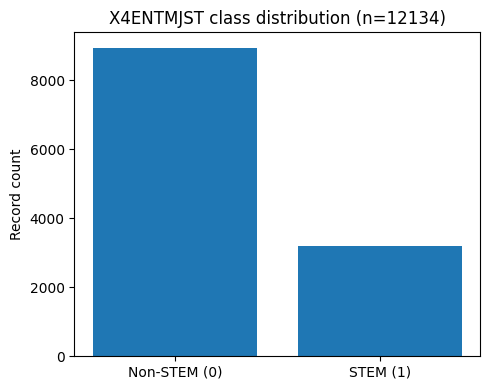

              precision    recall  f1-score   support

           0       0.82      0.92      0.87      1788
           1       0.66      0.45      0.53       639

    accuracy                           0.79      2427
   macro avg       0.74      0.68      0.70      2427
weighted avg       0.78      0.79      0.78      2427

Saved: /content/drive/MyDrive/newbenchmark/output3/stage1_classification_report.csv


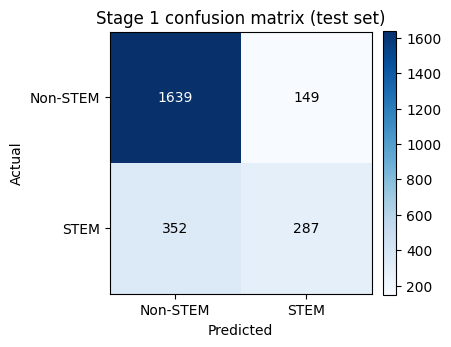

In [13]:
fig, ax = plt.subplots(figsize=(5, 4))
ax.bar(["Non-STEM (0)", "STEM (1)"], [class_counts_stage1[0], class_counts_stage1[1]])
ax.set_ylabel("Record count")
ax.set_title(f"X4ENTMJST class distribution (n={n_stage1})")
plt.tight_layout()
plt.savefig(out_path("fig_stage1_class_distribution.png"), dpi=200)
plt.show()

s1_report_df = pd.DataFrame(s1["_report_dict"]).transpose()
s1_report_path = out_path("stage1_classification_report.csv")
s1_report_df.to_csv(s1_report_path)
print(classification_report(s1["_y_test"], s1["_y_pred_test"], zero_division=0))
print(f"Saved: {s1_report_path}")

cm = confusion_matrix(s1["_y_test"], s1["_y_pred_test"], labels=[0, 1])
fig, ax = plt.subplots(figsize=(4.5, 4))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks([0, 1]); ax.set_xticklabels(["Non-STEM", "STEM"])
ax.set_yticks([0, 1]); ax.set_yticklabels(["Non-STEM", "STEM"])
ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
ax.set_title("Stage 1 confusion matrix (test set)")
for i in range(2):
    for j in range(2):
        ax.text(j, i, cm[i, j], ha="center", va="center",
                color="white" if cm[i, j] > cm.max() / 2 else "black")
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.savefig(out_path("fig_stage1_confusion_matrix.png"), dpi=200)
plt.show()


## Final comparison table -- Stages 1-6 plus the existing Stage 7 reference

Stage 7 is **not recomputed here** -- it is the frozen, unmodified 11-class
`X4ENTRYMAJ4Y` V3 CatBoost result (Macro-F1 = 0.2287), included only as a reference
point. No classes are merged or modified to produce it.

Two additions beyond the original design: (1) **ΔMacro-F1** relative to the previous
stage and relative to the Academic-only baseline, so the incremental value of each
added dimension is visible directly in the table rather than requiring mental
subtraction; (2) **STEM-class Precision/Recall/F1** for every binary stage, since
Macro-F1 alone can mask whether the minority (STEM) class is actually being
identified -- which matters directly for a recommendation-system use case.

In [14]:
comparison_rows = []
for stage_name, r in stage_results.items():
    comparison_rows.append({
        "Stage": stage_name, "Target": r["Target"], "N predictors": r["N predictors"],
        "Accuracy": r["Accuracy"], "Macro F1 (test)": r["Macro F1 (test)"],
        "ROC-AUC": r["ROC-AUC"], "CV Macro-F1 mean": r["CV Macro-F1 mean"],
        "CV Macro-F1 SD": r["CV Macro-F1 SD"],
        "STEM Precision": r["STEM Precision"], "STEM Recall": r["STEM Recall"], "STEM F1": r["STEM F1"],
    })

# Stage 7: existing, unmodified reference result -- not recomputed, not merged classes.
# No STEM-class breakdown: Stage 7 is an 11-class task, "STEM" is not one of its classes.
comparison_rows.append({
    "Stage": "Stage 7 (11-class X4ENTRYMAJ4Y, reference -- not recomputed here)",
    "Target": "X4ENTRYMAJ4Y", "N predictors": 377,
    "Accuracy": 0.3137, "Macro F1 (test)": 0.2287, "ROC-AUC": None,
    "CV Macro-F1 mean": 0.2244, "CV Macro-F1 SD": 0.0145,
    "STEM Precision": None, "STEM Recall": None, "STEM F1": None,
})

comparison_df = pd.DataFrame(comparison_rows)

# --- Delta columns: vs previous stage (within the Stage 1-6 ladder only) and vs
# Academic-only (Stage 2) baseline. Stage 1 and Stage 7 get no "vs previous stage"
# delta (Stage 1 has no predecessor in the ladder; Stage 7 is a different task/target,
# so a numeric delta against it would misleadingly imply the metrics are comparable).
ladder_order = ["Stage 2 (Academic only)", "Stage 3 (+ Career interests)",
                "Stage 4 (+ Skills/self-efficacy)", "Stage 5 (+ Behavioral/psychological)",
                "Stage 6 (+ Demographic/SES = full set)"]
ladder_f1_by_stage = {row["Stage"]: row["Macro F1 (test)"] for _, row in comparison_df.iterrows() if row["Stage"] in ladder_order}
academic_baseline_f1 = ladder_f1_by_stage["Stage 2 (Academic only)"]

delta_prev, delta_baseline = {}, {}
prev_f1 = None
for stage_name in ladder_order:
    f1 = ladder_f1_by_stage[stage_name]
    delta_prev[stage_name] = round(f1 - prev_f1, 4) if prev_f1 is not None else None
    delta_baseline[stage_name] = round(f1 - academic_baseline_f1, 4)
    prev_f1 = f1

comparison_df["Delta vs previous stage"] = comparison_df["Stage"].map(delta_prev)
comparison_df["Delta vs Academic-only"] = comparison_df["Stage"].map(delta_baseline)

comparison_path = out_path("staged_benchmark_results.csv")
comparison_df.to_csv(comparison_path, index=False)
print(comparison_df.to_string(index=False))
print(f"\nSaved: {comparison_path}")


                                                            Stage       Target  N predictors  Accuracy  Macro F1 (test)  ROC-AUC  CV Macro-F1 mean  CV Macro-F1 SD  STEM Precision  STEM Recall  STEM F1  Delta vs previous stage  Delta vs Academic-only
                                      Stage 1 (full eligible set)    X4ENTMJST           377    0.7936           0.7007   0.8166            0.7084          0.0110          0.6583       0.4491   0.5340                      NaN                     NaN
                                          Stage 2 (Academic only)    X4ENTMJST           240    0.7878           0.6811   0.7819            0.6770          0.0050          0.6615       0.3975   0.4966                      NaN                  0.0000
                                     Stage 3 (+ Career interests)    X4ENTMJST           291    0.7882           0.6864   0.7981            0.6942          0.0059          0.6543       0.4147   0.5077                   0.0053                  0.0053


## Progression figures

One primary figure (Macro-F1 across the ladder plus the 11-class reference, with
value labels for readability), and one secondary figure showing STEM-class recall
specifically across the same progression -- since a stage could leave Macro-F1
almost unchanged while still meaningfully shifting how well the minority class is
identified.

**Stage 7 is visually and conceptually separated from Stages 1-6 in the primary
figure below** (a gap, a distinct color, and its own caption note) rather than placed
as if it were simply the next bar in the same controlled comparison. Stages 1-6 hold
the target fixed (`X4ENTMJST`) and vary only the predictor set -- a genuine
one-variable-at-a-time comparison. Stage 7 changes the *target* (`X4ENTRYMAJ4Y`,
11-class) and comes from the separate, frozen V1-V6/CatBoost experiment, not from
this notebook's controlled protocol. The 0.7007 -> 0.2287 drop illustrates the effect
of increased task granularity; it is not a like-for-like performance comparison.

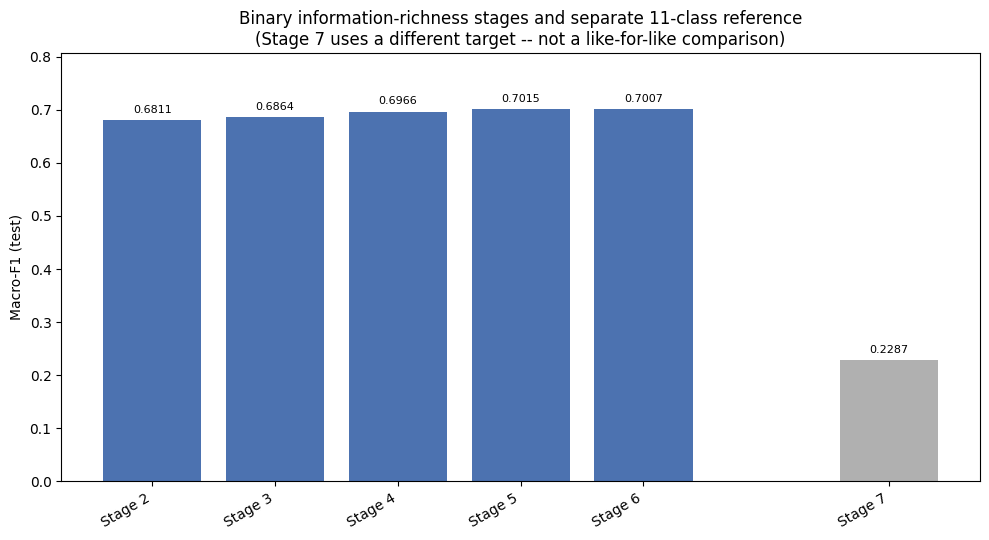

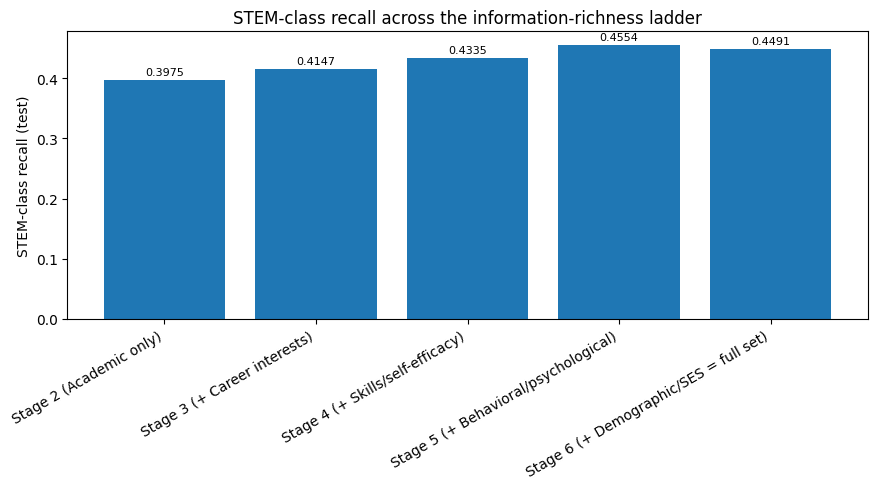

In [15]:
ladder_and_ref = comparison_df[comparison_df["Stage"] != "Stage 1 (full eligible set)"].copy()
# (Stage 1 is identical to Stage 6 and would visually duplicate it -- shown once, as Stage 6.)
x_positions = list(range(len(ladder_order))) + [len(ladder_order) + 1]  # gap before Stage 7
bar_colors = ["#4C72B0"] * len(ladder_order) + ["#B0B0B0"]
bar_labels = ladder_order + [comparison_df.iloc[-1]["Stage"]]
bar_values = [ladder_f1_by_stage[s] for s in ladder_order] + [comparison_df.iloc[-1]["Macro F1 (test)"]]

fig, ax = plt.subplots(figsize=(10, 5.5))
bars = ax.bar(x_positions, bar_values, color=bar_colors)
for x, val in zip(x_positions, bar_values):
    ax.text(x, val + 0.01, f"{val:.4f}", ha="center", va="bottom", fontsize=8)
ax.set_xticks(x_positions)
ax.set_xticklabels([s.split(" (")[0] for s in bar_labels], rotation=30, ha="right")
ax.set_ylabel("Macro-F1 (test)")
ax.set_title("Binary information-richness stages and separate 11-class reference\n"
             "(Stage 7 uses a different target -- not a like-for-like comparison)")
ax.set_ylim(0, max(bar_values) * 1.15)
plt.tight_layout()
plt.savefig(out_path("fig_staged_benchmark_macro_f1.png"), dpi=200)
plt.show()

ladder_df = comparison_df[comparison_df["Stage"].isin(ladder_order)].copy()
ladder_df["Stage"] = pd.Categorical(ladder_df["Stage"], categories=ladder_order, ordered=True)
ladder_df = ladder_df.sort_values("Stage")

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(ladder_df["Stage"], ladder_df["STEM Recall"])
for bar, val in zip(bars, ladder_df["STEM Recall"]):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005, f"{val:.4f}",
            ha="center", va="bottom", fontsize=8)
ax.set_ylabel("STEM-class recall (test)")
ax.set_title("STEM-class recall across the information-richness ladder")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig(out_path("fig_stage_ladder_stem_recall.png"), dpi=200)
plt.show()


## Uncertainty: paired cross-validation comparison (Stage 5 vs. Stage 6)

Every stage shares the same underlying rows and the same target array, so
`make_cv(y_train)` -- which determines fold membership from `y_train` alone -- assigns
the **same students to the same folds in every stage**. This means per-fold scores
across stages are paired, not independent, so the raw difference between Stage 5 and
Stage 6 (0.7015 vs. 0.7007 on the single held-out test split) can be examined via an
**exploratory paired comparison across the five matched CV folds**, rather than
eyeballing two overlapping mean-plus-or-minus-SD ranges.

**This is exploratory/supporting evidence, not a formal confirmatory significance
test.** Five CV folds are not five independent experiments -- they share overlapping
training data by construction -- so a paired t-test's p-value here is a secondary,
descriptive signal. The primary evidence is the fold-wise differences and their
mean/SD; the p-value is reported alongside for reference only, not as a threshold that
decides the conclusion.

In [16]:
from scipy import stats

s5_folds = stage_results["Stage 5 (+ Behavioral/psychological)"]["_cv_scores"]
s6_folds = stage_results["Stage 6 (+ Demographic/SES = full set)"]["_cv_scores"]

paired_diff = s6_folds - s5_folds
print(f"Stage 5 CV Macro-F1 per fold: {np.round(s5_folds, 4)}")
print(f"Stage 6 CV Macro-F1 per fold: {np.round(s6_folds, 4)}")
print(f"Paired difference (Stage 6 - Stage 5) per fold: {np.round(paired_diff, 4)}")
print(f"Mean paired difference: {paired_diff.mean():.4f} +/- {paired_diff.std():.4f}")

t_stat, p_value = stats.ttest_rel(s6_folds, s5_folds)
print(f"Exploratory paired t-test (Stage 6 vs Stage 5, secondary/supporting only): "
      f"t={t_stat:.3f}, p={p_value:.3f}")

print(f"\nPrimary evidence: the mean paired difference ({paired_diff.mean():.4f}) is small "
      f"relative to the fold-to-fold spread (SD {paired_diff.std():.4f}), across only 5 "
      f"matched folds. This exploratory paired comparison across the five matched CV "
      f"folds supports describing Stage 5 to Stage 6 as a PLATEAU -- performance not "
      f"materially changing once behavioral information is included -- rather than a "
      f"confirmed statistically significant difference in either direction. The p-value "
      f"above is reported for reference only and should not be treated as a formal "
      f"confirmatory test given the small, non-independent fold count.")


Stage 5 CV Macro-F1 per fold: [0.7119 0.6939 0.6943 0.7146 0.6992]
Stage 6 CV Macro-F1 per fold: [0.7264 0.6918 0.7095 0.7088 0.7056]
Paired difference (Stage 6 - Stage 5) per fold: [ 0.0144 -0.0021  0.0152 -0.0057  0.0064]
Mean paired difference: 0.0057 +/- 0.0085
Exploratory paired t-test (Stage 6 vs Stage 5, secondary/supporting only): t=1.333, p=0.253

Primary evidence: the mean paired difference (0.0057) is small relative to the fold-to-fold spread (SD 0.0085), across only 5 matched folds. This exploratory paired comparison across the five matched CV folds supports describing Stage 5 to Stage 6 as a PLATEAU -- performance not materially changing once behavioral information is included -- rather than a confirmed statistically significant difference in either direction. The p-value above is reported for reference only and should not be treated as a formal confirmatory test given the small, non-independent fold count.


## Comparison against Chang et al. (2023) and Nagy et al. (2023)

**Not presented as "we outperform" either study** -- evaluation protocols differ
(single 80/20 holdout vs. 5-fold CV means), and Chang et al.'s target
(`X4RFDGMJSTEM`, a completed/declared-degree construct) is confirmed by the codebook
to differ from the entry-intent construct used by both Nagy et al. and this
benchmark. The comparison below states what is actually comparable -- target
definition, sample, predictors, validation protocol -- and lets the numbers speak
without a superiority claim.

In [17]:
# External literature values (Chang et al. 2023; Nagy et al. 2023) -- hardcoded here
# because they are published external figures, not something this notebook computes.
# Clearly labeled as such; not to be confused with the live Stage 1 values below.
literature_comparison = pd.DataFrame([
    {
        "Study": "Chang et al. (2023)", "Target": "X4RFDGMJSTEM (completed/declared degree, DIFFERENT construct)",
        "Sample": "11,560", "Predictors": 102, "Model": "CART (decision tree)",
        "Validation": "80/20 holdout", "Accuracy": 0.80, "AUC": None, "Macro-F1": None,
    },
    {
        "Study": "Nagy et al. (2023)", "Target": "Entry-intent STEM (exact HSLS code not reported; aligned, not confirmed identical)",
        "Sample": "11,550", "Predictors": 104, "Model": "CatBoost",
        "Validation": "5-fold CV (mean)", "Accuracy": 0.790, "AUC": 0.801, "Macro-F1": None,
    },
    {
        "Study": "This study -- Stage 1/6 (live result)", "Target": "X4ENTMJST (official NCES entry-intent STEM composite)",
        "Sample": str(s1["N train"] + s1["N test"]), "Predictors": s1["N predictors"], "Model": "CatBoost (frozen V3 protocol)",
        "Validation": "80/20 holdout + 5-fold CV", "Accuracy": s1["Accuracy"], "AUC": s1["ROC-AUC"], "Macro-F1": s1["Macro F1 (test)"],
    },
])
print(literature_comparison.to_string(index=False))
literature_comparison.to_csv(out_path("literature_comparison.csv"), index=False)

print(f"\nAccuracy vs. Chang et al.: {s1['Accuracy']} vs. 0.80 (difference: {round(s1['Accuracy'] - 0.80, 4)})")
print(f"Accuracy vs. Nagy et al.:  {s1['Accuracy']} vs. 0.790 (difference: {round(s1['Accuracy'] - 0.790, 4)})")
print(f"AUC vs. Nagy et al.:       {s1['ROC-AUC']} vs. 0.801 (difference: {round(s1['ROC-AUC'] - 0.801, 4)})")
print("\nThis places the benchmark's predictive performance in the same general range "
      "as prior HSLS-based binary STEM-major studies. This is read as external "
      "validation that the modelling framework recovers a known, published pattern -- "
      "not as evidence of outperforming either study, given the protocol differences "
      "noted above.")


                                Study                                                                             Target Sample  Predictors                         Model                Validation  Accuracy    AUC  Macro-F1
                  Chang et al. (2023)                      X4RFDGMJSTEM (completed/declared degree, DIFFERENT construct) 11,560         102          CART (decision tree)             80/20 holdout    0.8000    NaN       NaN
                   Nagy et al. (2023) Entry-intent STEM (exact HSLS code not reported; aligned, not confirmed identical) 11,550         104                      CatBoost          5-fold CV (mean)    0.7900 0.8010       NaN
This study -- Stage 1/6 (live result)                              X4ENTMJST (official NCES entry-intent STEM composite)  12134         377 CatBoost (frozen V3 protocol) 80/20 holdout + 5-fold CV    0.7936 0.8166    0.7007

Accuracy vs. Chang et al.: 0.7936 vs. 0.80 (difference: -0.0064)
Accuracy vs. Nagy et al.:  0.7936 vs. 0.79

## What each experiment validates vs. contributes

Stated explicitly for the viva -- these are five distinct claims, not one story
repeated five times:

- **Binary benchmark (Stage 1/6):** validates that the modelling framework can recover
  a broad, previously-published HSLS major-choice pattern (STEM vs. non-STEM) at a
  performance level consistent with the literature. This is a validation check, not
  this thesis's novel contribution.
- **Information-richness ladder (Stages 2-5):** investigates the incremental
  predictive value of each student-information dimension, holding the task and
  protocol fixed. This is a genuine contribution -- neither Chang et al. nor Nagy et
  al. report a comparable dimensional ablation.
- **11-class experiment (Stage 7, existing V1-V6/CatBoost work):** tests the actual
  fine-grained major-recommendation problem this thesis proposes, which is
  substantially harder and not addressed by either published binary study.
- **V1-V6 / CatBoost / Set E investigations (existing work):** test whether standard
  modelling interventions (SMOTE, feature selection, tuning, stacking, an alternative
  model family, a reduced predictor set) can improve on the fine-grained task's
  ceiling.
- **SHAP / error analysis (existing work):** explains what the selected fine-grained
  model actually learned and where its errors concentrate, given that ceiling.

## Results Summary / Key Finding

Generated programmatically from `comparison_df` below -- every number in this section
is pulled from the actual results table, not typed in.

In [18]:
stage2_f1 = comparison_df.loc[comparison_df["Stage"] == "Stage 2 (Academic only)", "Macro F1 (test)"].iloc[0]
stage3_f1 = comparison_df.loc[comparison_df["Stage"] == "Stage 3 (+ Career interests)", "Macro F1 (test)"].iloc[0]
stage4_f1 = comparison_df.loc[comparison_df["Stage"] == "Stage 4 (+ Skills/self-efficacy)", "Macro F1 (test)"].iloc[0]
stage5_f1 = comparison_df.loc[comparison_df["Stage"] == "Stage 5 (+ Behavioral/psychological)", "Macro F1 (test)"].iloc[0]
stage6_f1 = comparison_df.loc[comparison_df["Stage"] == "Stage 6 (+ Demographic/SES = full set)", "Macro F1 (test)"].iloc[0]
stage1_f1 = comparison_df.loc[comparison_df["Stage"] == "Stage 1 (full eligible set)", "Macro F1 (test)"].iloc[0]
stage1_acc = comparison_df.loc[comparison_df["Stage"] == "Stage 1 (full eligible set)", "Accuracy"].iloc[0]
stage1_auc = comparison_df.loc[comparison_df["Stage"] == "Stage 1 (full eligible set)", "ROC-AUC"].iloc[0]
stage7_row = comparison_df[comparison_df["Stage"].str.startswith("Stage 7")].iloc[0]
stage7_f1 = stage7_row["Macro F1 (test)"]
stage7_acc = stage7_row["Accuracy"]

ladder_f1 = [stage2_f1, stage3_f1, stage4_f1, stage5_f1, stage6_f1]
ladder_names = ["Stage 2 (Academic)", "Stage 3 (+Career)", "Stage 4 (+Skills)", "Stage 5 (+Behavioral)", "Stage 6 (+Demographic, full set)"]
ladder_deltas_prev = comparison_df.loc[comparison_df["Stage"].isin(ladder_order), "Delta vs previous stage"].tolist()
ladder_deltas_baseline = comparison_df.loc[comparison_df["Stage"].isin(ladder_order), "Delta vs Academic-only"].tolist()
is_monotonic = all(b >= a for a, b in zip(ladder_f1, ladder_f1[1:]))
best_stage_idx = int(np.argmax(ladder_f1))
gap_binary_to_11class = round(stage1_f1 - stage7_f1, 4)

stem_recalls = comparison_df.loc[comparison_df["Stage"].isin(ladder_order), "STEM Recall"].tolist()
stem_f1s = comparison_df.loc[comparison_df["Stage"].isin(ladder_order), "STEM F1"].tolist()

print("=" * 70)
print("RESULTS SUMMARY (generated from comparison_df -- not hand-written)")
print("=" * 70)

print(f"\n1. Published context (not replicated, aligned): Nagy et al. (2023) reported "
      f"CatBoost AUC=0.801 (SD 0.007) / Accuracy=0.790 (SD 0.006) on a binary "
      f"STEM/non-STEM HSLS task (104 predictors, 5-fold CV); Chang et al. (2023) "
      f"reported 0.80 accuracy on a different, completion-oriented target. This "
      f"benchmark's own full-predictor Stage 1/6 result: Accuracy={stage1_acc}, "
      f"ROC-AUC={stage1_auc}, Macro-F1={stage1_f1} (377 codebook-audited predictors, "
      f"frozen V3 CatBoost protocol) -- read as external validation that the "
      f"framework recovers a known published pattern, not a claim of outperforming "
      f"either study (see the literature comparison table above).")

print(f"\n2. Leakage audit: no direct target-derived predictors were identified in "
      f"the frozen Set D predictor set under the documented leakage audit (0 matched "
      f"the explicit target-family exclusion list by name, and no S4/X4-prefixed, "
      f"second-follow-up-wave predictors were found in this predictor set under the "
      f"wave check applied); 5 variables flagged by the automated keyword scan were "
      f"manually reviewed and retained with recorded justification (see "
      f"`predictor_leakage_audit.csv`); 0 left unresolved. Frozen eligible set: "
      f"{len(ELIGIBLE_PREDICTORS)} predictors, used unchanged (same order) across "
      f"Stages 1-6.")

print(f"\n3. Information richness (Stages 2-6): Macro-F1 by stage -- "
      + ", ".join(f'{n}={v}' for n, v in zip(ladder_names, ladder_f1)))
print(f"   Delta vs previous stage: {ladder_deltas_prev}")
print(f"   Delta vs Academic-only baseline: {ladder_deltas_baseline}")
print(f"   Monotonically non-decreasing across the ladder: {is_monotonic}")
print(f"   Best-performing stage in the ladder: {ladder_names[best_stage_idx]} "
      f"(Macro-F1={ladder_f1[best_stage_idx]})")
print(f"   Reading: successive additions were associated with modest improvements in "
      f"held-out Macro-F1 through the behavioral/psychological stage, while the "
      f"final demographic/SES addition produced no material further improvement "
      f"(see the paired CV test above) -- described as a plateau, not a decline.")

print(f"\n4. STEM-class detail across the ladder (recall / F1): "
      + ", ".join(f'{n}: {r}/{f}' for n, r, f in zip(ladder_names, stem_recalls, stem_f1s)))
print(f"   Even at Stage 1/6's overall Accuracy={stage1_acc}, STEM-class F1 "
      f"({s1['STEM F1']}) and recall ({s1['STEM Recall']}) are substantially lower "
      f"than the non-STEM class -- minority-class difficulty is visible even in "
      f"this simpler binary task, before granularity increases to 11 classes.")

print(f"\n5. Internal consistency: Stage 1 and Stage 6 are identical by construction "
      f"(Macro-F1={stage1_f1} for both) -- verified above, not merely observed.")

print(f"\n6. Task complexity: binary Stage 1/6 Macro-F1={stage1_f1} vs. 11-class "
      f"Stage 7 (reference, not recomputed) Macro-F1={stage7_f1} -- a difference of "
      f"{gap_binary_to_11class}. Accuracy tells a similar story: {stage1_acc} (binary) "
      f"vs. {stage7_acc} (11-class). This quantifies how much harder fine-grained "
      f"major prediction is than broad binary field prediction; it is not a failure "
      f"of the 11-class model, and it is not the same metric scale, so this "
      f"difference should be reported descriptively, not as a direct performance "
      f"ranking between the two tasks.")

print(f"\n7. Metric-comparability caveat: Accuracy and ROC-AUC are reported for the "
      f"binary stages because that is what the published literature reports; they "
      f"remain not directly comparable to the 11-class task's Macro-F1 (different "
      f"chance baselines, different class structure), consistent with the caveat "
      f"already established earlier in this thesis.")


RESULTS SUMMARY (generated from comparison_df -- not hand-written)

1. Published context (not replicated, aligned): Nagy et al. (2023) reported CatBoost AUC=0.801 (SD 0.007) / Accuracy=0.790 (SD 0.006) on a binary STEM/non-STEM HSLS task (104 predictors, 5-fold CV); Chang et al. (2023) reported 0.80 accuracy on a different, completion-oriented target. This benchmark's own full-predictor Stage 1/6 result: Accuracy=0.7936, ROC-AUC=0.8166, Macro-F1=0.7007 (377 codebook-audited predictors, frozen V3 CatBoost protocol) -- read as external validation that the framework recovers a known published pattern, not a claim of outperforming either study (see the literature comparison table above).

2. Leakage audit: no direct target-derived predictors were identified in the frozen Set D predictor set under the documented leakage audit (0 matched the explicit target-family exclusion list by name, and no S4/X4-prefixed, second-follow-up-wave predictors were found in this predictor set under the wave c